In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

print(df.shape)
df.info()
df.describe()

(891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.to_csv("titanic.csv", index=False)

In [7]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [8]:
# deck: 77.22% missing — too high to impute reliably, so I drop the column
df = df.drop(columns=["deck"])

# embarked / embark_town: 0.22% missing each — under the 5% threshold, so I drop those rows
df = df.dropna(subset=["embarked", "embark_town"])

# age: 19.87% missing — within the 5%–30% band, so I impute with the median
df["age"] = df["age"].fillna(df["age"].median())

print(df.isnull().sum())
print(df.shape)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
(889, 14)


### Handling missing values

Four columns had missing values, so I applied the 5%/30% threshold rule to each one.

**deck (77.22% missing):** This is far too high to impute reliably — filling in
three out of every four values would mean mostly guessing, not estimating. I chose
to drop the column entirely rather than encode it as its own "missing" category,
since with this much of the column absent, keeping it would add more noise than
signal to the analysis and modelling steps that follow.

**age (19.87% missing):** This falls in the 5%–30% band, so I imputed it rather than
dropping rows. I used the median because age is right-skewed by a small number of
older passengers, and the median is less affected by that skew than the mean.

**embarked (0.22% missing) and embark_town (0.22% missing):** Both are well under
the 5% threshold, and they're missing for the same two passengers. Dropping those
two rows removes a negligible fraction of the dataset (889 of 891 rows remain) and
avoids inventing a port of embarkation for them.

After this cleaning, the dataset has 889 rows and 14 columns, with no missing
values remaining.

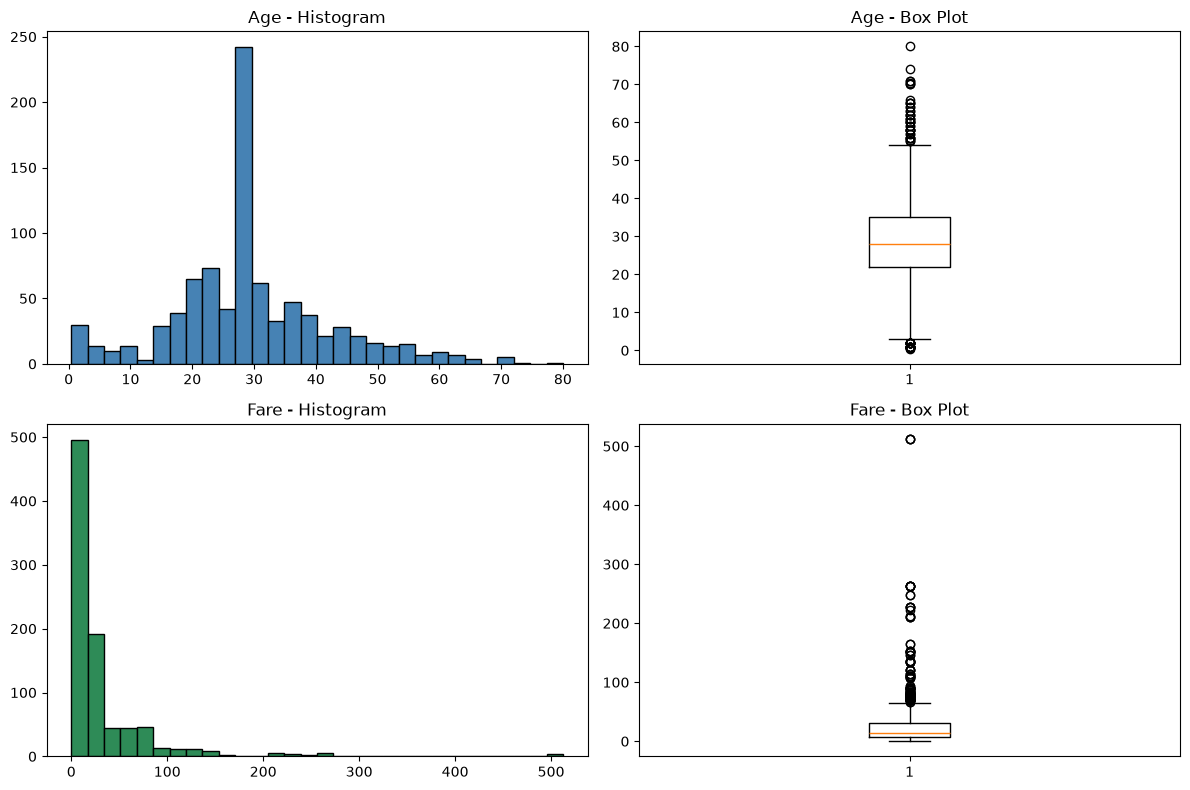

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["age"], bins=30, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Age - Histogram")

axes[0, 1].boxplot(df["age"])
axes[0, 1].set_title("Age - Box Plot")

axes[1, 0].hist(df["fare"], bins=30, color="seagreen", edgecolor="black")
axes[1, 0].set_title("Fare - Histogram")

axes[1, 1].boxplot(df["fare"])
axes[1, 1].set_title("Fare - Box Plot")

plt.tight_layout()
plt.savefig("age_fare_distributions.png")
plt.show()

In [13]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

age_count, age_lo, age_hi = iqr_outlier_count(df["age"])
fare_count, fare_lo, fare_hi = iqr_outlier_count(df["fare"])

print(f"Age outliers: {age_count} (bounds: {age_lo:.2f} to {age_hi:.2f})")
print(f"Fare outliers: {fare_count} (bounds: {fare_lo:.2f} to {fare_hi:.2f})")

Age outliers: 65 (bounds: 2.50 to 54.50)
Fare outliers: 114 (bounds: -26.76 to 65.66)


In [14]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print(f"Fare mean: {fare_mean:.2f}")
print(f"Fare median: {fare_median:.2f}")
print(f"Fare mode: {fare_mode:.2f}")

Fare mean: 32.10
Fare median: 14.45
Fare mode: 8.05


### Univariate analysis — age and fare

Using the IQR rule, age has 65 outliers (values outside 2.50–54.50), mostly older
passengers, visible as points above the upper whisker in the box plot. Fare has 114
outliers (values outside -26.76–65.66) — the lower bound is negative, which isn't
meaningful since fares can't be negative, so in practice all of fare's outliers are
high-fare passengers.

For fare: mean = 32.10, median = 14.45, mode = 8.05. Since mean > median > mode,
the distribution is right-skewed. This matches the histogram, which shows most
passengers paid a low fare, with a long tail of passengers who paid much more —
pulling the mean well above the median.

In [18]:
# (a) by sex
survival_by_sex = {}
for s in df["sex"].unique():
    mask = df["sex"] == s
    survival_by_sex[s] = df.loc[mask, "survived"].mean()
print("Survival rate by sex:")
print(survival_by_sex)

# (b) by pclass
survival_by_pclass = {}
for p in sorted(df["pclass"].unique()):
    mask = df["pclass"] == p
    survival_by_pclass[p] = df.loc[mask, "survived"].mean()
print("\nSurvival rate by pclass:")
print(survival_by_pclass)

# (c) by sex and pclass together
survival_by_sex_pclass = {}
for s in df["sex"].unique():
    for p in sorted(df["pclass"].unique()):
        mask = (df["sex"] == s) & (df["pclass"] == p)
        survival_by_sex_pclass[(s, p)] = df.loc[mask, "survived"].mean()
print("\nSurvival rate by sex and pclass:")
for k, v in survival_by_sex_pclass.items():
    print(k, "->", round(v, 3))

Survival rate by sex:
{'male': np.float64(0.18890814558058924), 'female': np.float64(0.7403846153846154)}

Survival rate by pclass:
{np.int64(1): np.float64(0.6261682242990654), np.int64(2): np.float64(0.47282608695652173), np.int64(3): np.float64(0.24236252545824846)}

Survival rate by sex and pclass:
('male', np.int64(1)) -> 0.369
('male', np.int64(2)) -> 0.157
('male', np.int64(3)) -> 0.135
('female', np.int64(1)) -> 0.967
('female', np.int64(2)) -> 0.921
('female', np.int64(3)) -> 0.5


          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


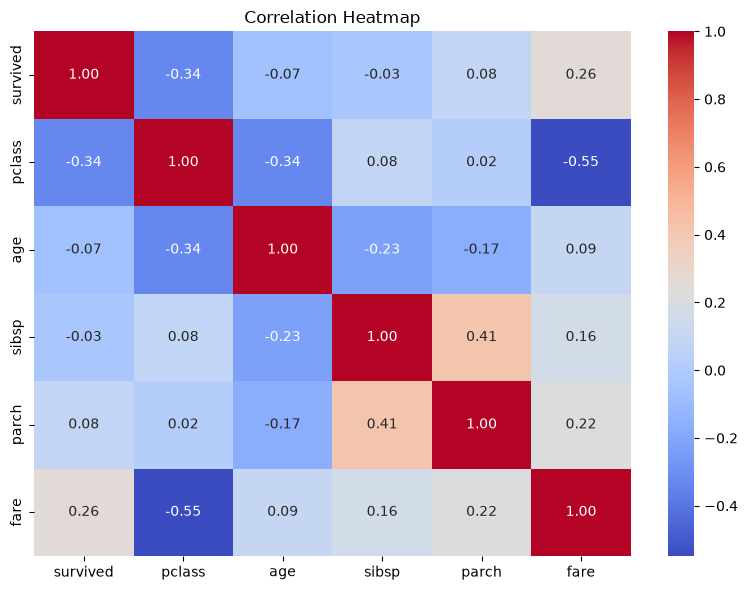

In [16]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_matrix = df[corr_cols].corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

In [19]:
corr_pairs = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[~corr_pairs.index.map(lambda x: x[0] > x[1])]  # drop duplicate mirrored pairs
top2 = corr_pairs.abs().sort_values(ascending=False).head(2)
print(top2)

fare   pclass    0.548193
parch  sibsp     0.414542
dtype: float64


### Bivariate analysis

Survival rate by sex: 74.0% of females survived, versus 18.9% of males — a large gap.

Survival rate by pclass: 62.6% for 1st class, 47.3% for 2nd class, and 24.2% for 3rd
class — survival drops steadily as class gets lower.

Survival rate by sex and pclass together: the two factors compound. First-class
women survived at 96.7%, and second-class women at 92.1%, both close to certain
survival. Even third-class women survived over half the time (50.0%). Men fared far
worse across every class, from 36.9% in 1st class down to 13.5% in 3rd class — even
a first-class male passenger was less likely to survive than a third-class female
passenger.

### Correlation heatmap

The two strongest correlations among the six numeric columns are:

1. **fare and pclass (-0.548):** Higher-numbered classes (3rd class) had much lower
   fares, which makes sense since pclass is essentially a proxy for the price and
   quality of the ticket.
2. **parch and sibsp (0.415):** Passengers travelling with more parents/children
   also tended to travel with more siblings/spouses — both reflect the same
   underlying pattern of travelling as a family rather than alone.

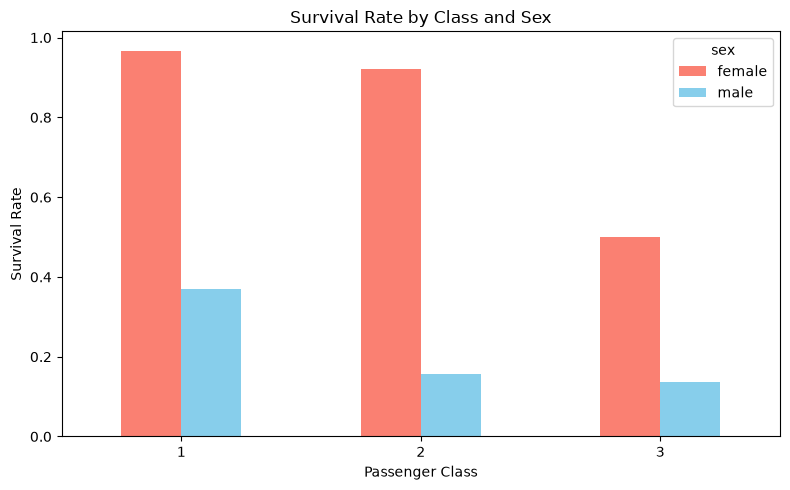

In [24]:
survival_grouped = df.groupby(["pclass", "sex"])["survived"].mean().unstack()
survival_grouped.plot(kind="bar", figsize=(8, 5), color=["salmon", "skyblue"])
plt.title("Survival Rate by Class and Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart1_survival_by_class_sex.png")
plt.show()

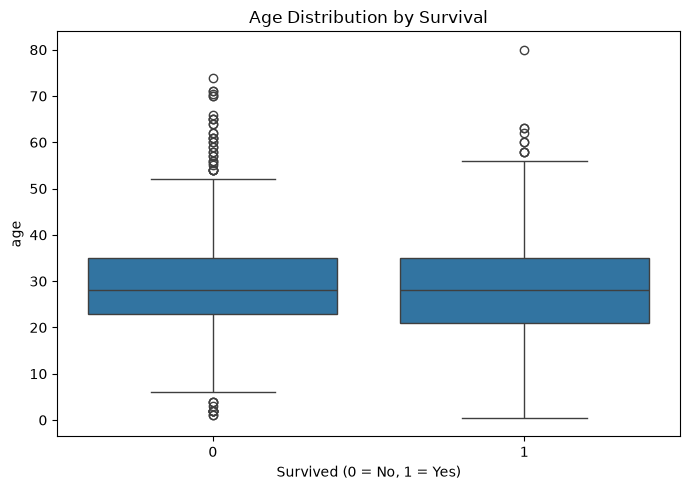

In [25]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="survived", y="age", data=df)
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.tight_layout()
plt.savefig("chart2_age_by_survival.png")
plt.show()

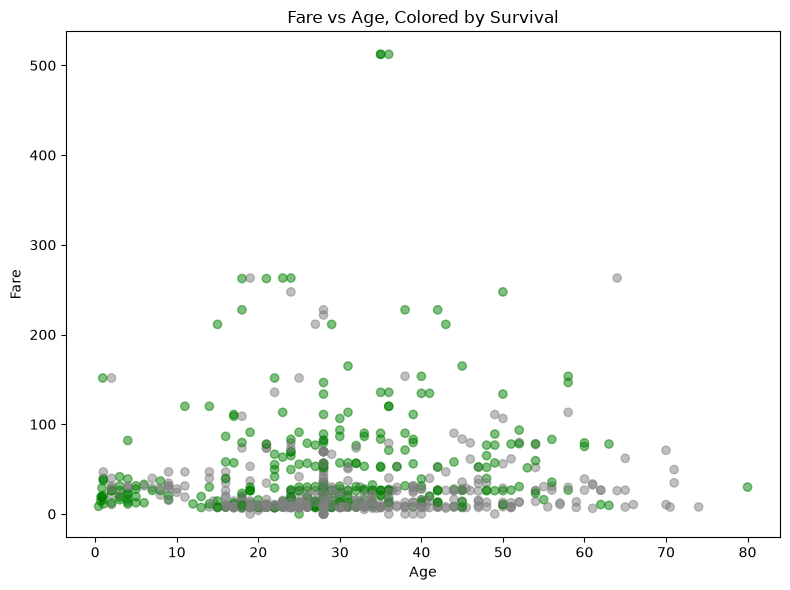

In [26]:
plt.figure(figsize=(8, 6))
colors = df["survived"].map({0: "gray", 1: "green"})
plt.scatter(df["age"], df["fare"], c=colors, alpha=0.5)
plt.title("Fare vs Age, Colored by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("chart3_fare_vs_age_survival.png")
plt.show()

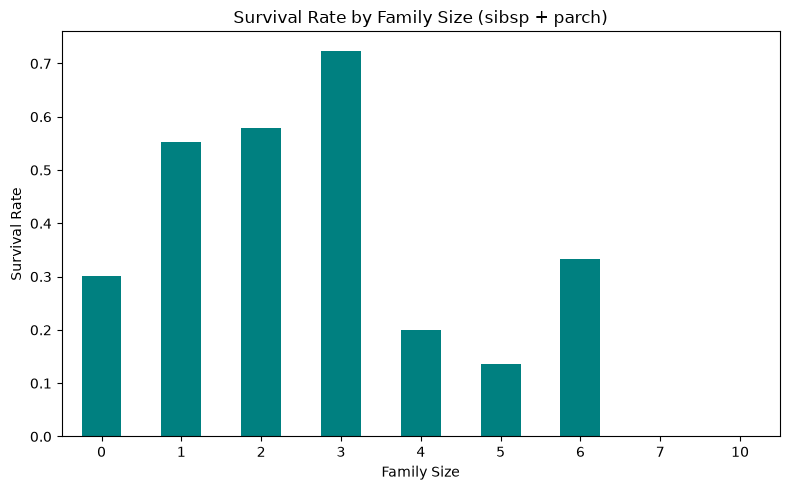

In [27]:
df["family_size"] = df["sibsp"] + df["parch"]
survival_by_family = df.groupby("family_size")["survived"].mean()
survival_by_family.plot(kind="bar", figsize=(8, 5), color="teal")
plt.title("Survival Rate by Family Size (sibsp + parch)")
plt.ylabel("Survival Rate")
plt.xlabel("Family Size")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart4_survival_by_family_size.png")
plt.show()

### Multivariate data story

**Chart 1 — Survival rate by class and sex:** This chart makes clear that sex and
class both drove survival, and sex was the stronger factor. Women survived at over
90% in 1st and 2nd class and 50% in 3rd class, while men never rose above 37% even
in 1st class. Class alone doesn't explain the pattern — the gap between male and
female survival within each class is far bigger than the gap between classes.

**Chart 2 — Age distribution by survival:** The age spread looks similar for
survivors and non-survivors — both have a median around 28 and a similar
interquartile range. The clearest difference is at the low end: non-survivors have
almost no passengers under about 5, while survivors include several very young
children with fares as low as near 0, closer to the bottom of the box. This hints
that very young children had a slightly better chance of survival, consistent with
"women and children first," though age alone is a weaker signal than sex or class.

**Chart 3 — Fare vs age, colored by survival:** Green (survived) points are denser
in the upper part of the fare range, while gray (did not survive) points dominate
the low-fare band under about 20. This lines up with the class finding, since fare
is closely tied to pclass — passengers who paid more tended to survive more often,
regardless of their age.

**Chart 4 — Survival rate by family size:** Passengers travelling alone (family
size 0) survived at only 30.3%. Survival rises for small families, peaking at family
size 3 (72.3%), then falls again for family sizes 4 and up, dropping to 13.6% at
family size 5. This suggests a small family offered mutual help in reaching a
lifeboat, but a very large family may have been harder to keep together and evacuate
as a group, especially since very large families were more common in 3rd class.

**Overall story:** Survival on the Titanic was driven mainly by sex (women survived
far more often than men), then by class and fare (wealthier, higher-class
passengers survived more often), with a smaller, secondary effect where very young
children and passengers in small family groups did somewhat better than solo
travellers or those in very large families.

In [28]:
from sklearn.preprocessing import StandardScaler

print("Before standardization:")
print(df[["age", "fare"]].agg(["mean", "std"]))

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[["age", "fare"]])

age_z = scaled_values[:, 0]
fare_z = scaled_values[:, 1]

print("\nAfter standardization:")
print(f"age_z  -> mean: {age_z.mean():.4f}, std: {age_z.std():.4f}")
print(f"fare_z -> mean: {fare_z.mean():.4f}, std: {fare_z.std():.4f}")

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
age_z  -> mean: 0.0000, std: 1.0000
fare_z -> mean: 0.0000, std: 1.0000


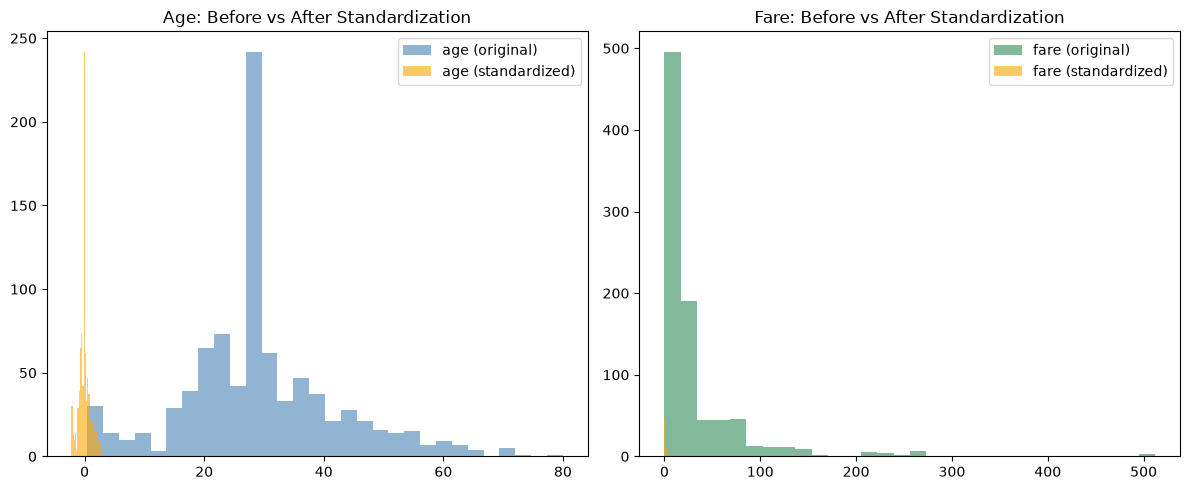

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["age"], bins=30, alpha=0.6, label="age (original)", color="steelblue")
axes[0].hist(age_z, bins=30, alpha=0.6, label="age (standardized)", color="orange")
axes[0].legend()
axes[0].set_title("Age: Before vs After Standardization")

axes[1].hist(df["fare"], bins=30, alpha=0.6, label="fare (original)", color="seagreen")
axes[1].hist(fare_z, bins=30, alpha=0.6, label="fare (standardized)", color="orange")
axes[1].legend()
axes[1].set_title("Fare: Before vs After Standardization")

plt.tight_layout()
plt.savefig("standardization_check.png")
plt.show()

### Exploratory standardization check (age and fare)

I standardized age and fare using z = (x - mean) / std, purely as an exploratory
sanity check — this is separate from the modeling pipeline, which will do its own
train-only scaling later. Before standardization, age and fare have their original
means and standard deviations; after standardization, both columns have a mean of
approximately 0 and a standard deviation of approximately 1, confirming the
transformation worked as expected. The overlaid histograms show the standardized
distributions are re-centered at 0 and rescaled, while keeping the same shape as
the originals (fare remains right-skewed even after standardization, since z-scoring
shifts and rescales a distribution but does not change its shape).